In [2]:
# ==================================================
# ==== MATHEMATICS FOR DATA SCIENCE - A00096829 ====
# ==================================================

# Dataset Name
# ===============
# MDR_RR_TB_burden_estimates_2026-03-06.csv

In [3]:
# REQURIED LIBRARIES
# ===================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from scipy.stats import poisson, norm, chisquare, kstest, expon

In [4]:
# DATASET LOADING (CSV file)
# ==========================

df = pd.read_csv("MDR_RR_TB_burden_estimates_2026-03-06.csv")
print("The dataset is uploaded sucessfully")

The dataset is uploaded sucessfully


In [5]:
# DATA CLEANING
# =============

# Remove rows that contain any null values
df = df.dropna()

print("=====================================================")

# Reset index after removing rows
df = df.reset_index(drop=True)

# Identify numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Convert numeric columns to integer
df[numeric_cols] = df[numeric_cols].astype(int)

# Check cleaned dataset
print("\nCleaned Dataset Shape:", df.shape)
print("\nRemaining Missing Values:")
print(df.isnull().sum())

print("=====================================================")

print(" print the five rows of cleaned dataset.")

display(
    df.head(5).style
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('background-color', '#ecf0f1')]}
    ])
)

print("=====================================================")

# Save cleaned dataset
df.to_csv("clean_tb_dataset.csv", index=False)
print("\nSuccessfully cleaned and saved above dataset.")



Cleaned Dataset Shape: (1795, 20)

Remaining Missing Values:
country                             0
iso2                                0
iso3                                0
iso_numeric                         0
g_whoregion                         0
year                                0
source_rr_new                       0
e_rr_pct_new                        0
e_rr_pct_new_lo                     0
e_rr_pct_new_hi                     0
source_rr_ret                       0
e_rr_pct_ret                        0
e_rr_pct_ret_lo                     0
e_rr_pct_ret_hi                     0
e_inc_rr_num                        0
e_inc_rr_num_lo                     0
e_inc_rr_num_hi                     0
e_rr_in_notified_labconf_pulm       0
e_rr_in_notified_labconf_pulm_lo    0
e_rr_in_notified_labconf_pulm_hi    0
dtype: int64
 print the five rows of cleaned dataset.


,country,iso2,iso3,iso_numeric,g_whoregion,year,source_rr_new,e_rr_pct_new,e_rr_pct_new_lo,e_rr_pct_new_hi,source_rr_ret,e_rr_pct_ret,e_rr_pct_ret_lo,e_rr_pct_ret_hi,e_inc_rr_num,e_inc_rr_num_lo,e_inc_rr_num_hi,e_rr_in_notified_labconf_pulm,e_rr_in_notified_labconf_pulm_lo,e_rr_in_notified_labconf_pulm_hi
0,Afghanistan,AF,AFG,4,EMR,2015,Surveillance,8,3,18,Surveillance,28,24,32,6400,0,13000,1400,600,3000
1,Afghanistan,AF,AFG,4,EMR,2016,Surveillance,7,3,14,Surveillance,24,22,28,5500,35,11000,1400,380,2400
2,Afghanistan,AF,AFG,4,EMR,2017,Surveillance,6,3,11,Surveillance,21,19,24,4800,380,9300,1600,880,2400
3,Afghanistan,AF,AFG,4,EMR,2018,Surveillance,5,2,8,Surveillance,18,17,20,4200,620,7800,1300,770,1900
4,Afghanistan,AF,AFG,4,EMR,2019,Surveillance,4,2,6,Surveillance,16,15,17,3600,730,6400,1200,690,1600



Successfully cleaned and saved above dataset.


In [6]:
# Display basic information (column names)
# ----------------------------------------

print("Original Dataset Shape:", df.shape)
print("\n" + "="*40)
print("DATASET COLUMN NAMES")
print("="*40)

for i, col in enumerate(df.columns, 1):
    print(f"{i:>2}. {col}")

Original Dataset Shape: (1795, 20)

DATASET COLUMN NAMES
 1. country
 2. iso2
 3. iso3
 4. iso_numeric
 5. g_whoregion
 6. year
 7. source_rr_new
 8. e_rr_pct_new
 9. e_rr_pct_new_lo
10. e_rr_pct_new_hi
11. source_rr_ret
12. e_rr_pct_ret
13. e_rr_pct_ret_lo
14. e_rr_pct_ret_hi
15. e_inc_rr_num
16. e_inc_rr_num_lo
17. e_inc_rr_num_hi
18. e_rr_in_notified_labconf_pulm
19. e_rr_in_notified_labconf_pulm_lo
20. e_rr_in_notified_labconf_pulm_hi


In [7]:
# Variables in a dataset and it's meanings
# ----------------------------------------

columns = [
"country","iso2","iso3","iso_numeric","g_whoregion","year","source_rr_new","e_rr_pct_new","e_rr_pct_new_lo",
"e_rr_pct_new_hi","source_rr_ret","e_rr_pct_ret","e_rr_pct_ret_lo","e_rr_pct_ret_hi","e_inc_rr_num",
"e_inc_rr_num_lo","e_inc_rr_num_hi","e_rr_in_notified_labconf_pulm","e_rr_in_notified_labconf_pulm_lo",
"e_rr_in_notified_labconf_pulm_hi"]

meanings = [
"Country name","2-letter country code","3-letter country code","Numeric country code","WHO region",
"Year of estimate","Data source for new TB cases","Estimated % of RR-TB in new TB cases","Lower confidence bound",
"Upper confidence bound","Data source for retreatment cases","Estimated % RR-TB in retreatment cases","Lower bound",
"Upper bound","Estimated number of RR-TB cases","Lower estimate","Upper estimate","RR-TB cases detected in labs",
"Lower estimate","Upper estimate"]

# Print table header
print(f"{'Column':<40} | Meaning")
print("-"*80)

# Print rows
for c, m in zip(columns, meanings):
    print(f"{c:<40} | {m}")

Column                                   | Meaning
--------------------------------------------------------------------------------
country                                  | Country name
iso2                                     | 2-letter country code
iso3                                     | 3-letter country code
iso_numeric                              | Numeric country code
g_whoregion                              | WHO region
year                                     | Year of estimate
source_rr_new                            | Data source for new TB cases
e_rr_pct_new                             | Estimated % of RR-TB in new TB cases
e_rr_pct_new_lo                          | Lower confidence bound
e_rr_pct_new_hi                          | Upper confidence bound
source_rr_ret                            | Data source for retreatment cases
e_rr_pct_ret                             | Estimated % RR-TB in retreatment cases
e_rr_pct_ret_lo                          | Lower bound
e_rr_p

In [8]:
# STEP-1 LINEAR ALGEBRA - VECTOR OPERATIONS
# =========================================

# Load cleaned dataset
df = pd.read_csv("clean_tb_dataset.csv")

# Select variables from cleaned dataset
v_new = df["e_rr_pct_new"].values
v_ret = df["e_rr_pct_ret"].values

# Convert to numpy vectors
v_new = np.array(v_new)
v_ret = np.array(v_ret)

# Dot Product
dot_product = np.dot(v_new, v_ret)

# Vector Norms
norm_v_new = np.linalg.norm(v_new)
norm_v_ret = np.linalg.norm(v_ret)

# Cosine Similarity
cosine_similarity = dot_product / (norm_v_new * norm_v_ret)

# Create results table
metrics = ["Dot Product", "Norm of v_new", "Norm of v_ret", "Cosine Similarity"]
values = [dot_product, norm_v_new, norm_v_ret, cosine_similarity]

results = pd.DataFrame({"Metric": metrics, "Value": values})

print("VECTOR ANALYSIS SUMMARY")
display(results)

VECTOR ANALYSIS SUMMARY


,Metric,Value
0,Dot Product,218439.000000
1,Norm of v_new,316.069613
2,Norm of v_ret,873.080180
3,Cosine Similarity,0.791577


In [9]:
# STEP-2 LINEAR ALGEBRA - MATRICES
# ================================

# Data matrix
X = df[["e_rr_pct_new", "e_rr_pct_ret", "e_inc_rr_num"]].values
print("Data Matrix: ")
print(X[:5])

# XᵀX matrix
XtX = X.T @ X
print("\nXᵀX:\n", XtX)

# Rank and Determinant
print("\nRank of X:", np.linalg.matrix_rank(X))
print("Determinant of XᵀX:", np.linalg.det(XtX))

Data Matrix: 
[[   8   28 6400]
 [   7   24 5500]
 [   6   21 4800]
 [   5   18 4200]
 [   4   16 3600]]

XᵀX:
 [[       99900       218439     37970536]
 [      218439       762269    102107358]
 [    37970536    102107358 224245330559]]

Rank of X: 3
Determinant of XᵀX: 5.929681334964054e+21


In [10]:
# STEP-3 DESCRIPTIVE STATISTICS & EDA
# ===================================

# Select two key variables from dataset
var_new = df["e_rr_pct_new"]
var_ret = df["e_rr_pct_ret"]

# Compute Summary Statistics
summary_stats = df[["e_rr_pct_new","e_rr_pct_ret"]].agg(["mean","var","skew","kurt"])
summary_stats.columns = ["New Cases","Retreatment Cases"]
summary_stats.index = ["Mean","Variance","Skewness","Kurtosis"]

# Print Summary Results
print("SUMMARY STATISTICS")
display(summary_stats)

SUMMARY STATISTICS


,New Cases,Retreatment Cases
Mean,3.635655,15.186072
Variance,42.460267,194.153764
Skewness,3.392462,2.114921
Kurtosis,11.833467,5.350430


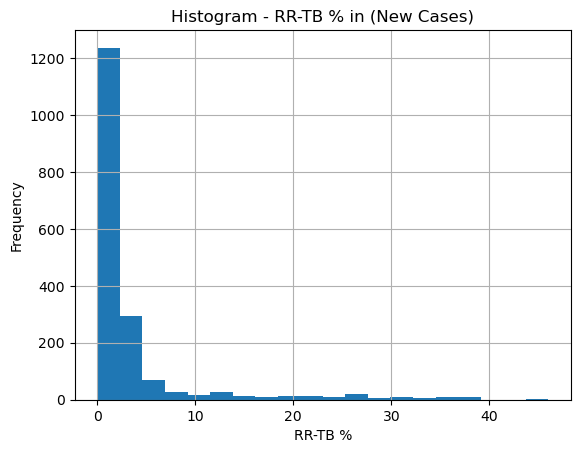

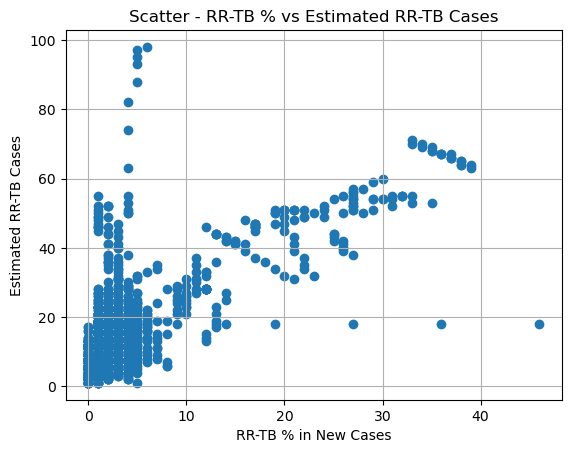

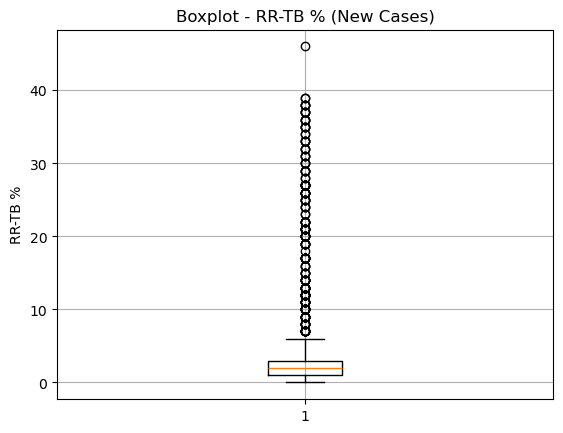

In [11]:
# Visualisation Graphs(Plots)
# ---------------------------

# Plot configurations (title, xlabel, ylabel)
plots = [
    (plt.hist, v_new, "Histogram - RR-TB % in (New Cases)", "RR-TB %", "Frequency"),
    (plt.scatter, (v_new, v_ret), "Scatter - RR-TB % vs Estimated RR-TB Cases", "RR-TB % in New Cases", 
                                  "Estimated RR-TB Cases"),
    (plt.boxplot, v_new, "Boxplot - RR-TB % (New Cases)", "", "RR-TB %")
]

# Generate plots - Histogram, Scatter, Box Plots
for func, data, title, xlab, ylab in plots:
    plt.figure()
    func(*data) if isinstance(data, tuple) else func(data, bins=20) if func==plt.hist else func(data)
    plt.title(title); plt.xlabel(xlab); plt.ylabel(ylab)
    plt.grid(True); plt.show()

Correlation Matrix:
               e_rr_pct_new  e_rr_pct_ret  e_inc_rr_num
e_rr_pct_new      1.000000      0.732622      0.166579
e_rr_pct_ret      0.732622      1.000000      0.117669
e_inc_rr_num      0.166579      0.117669      1.000000


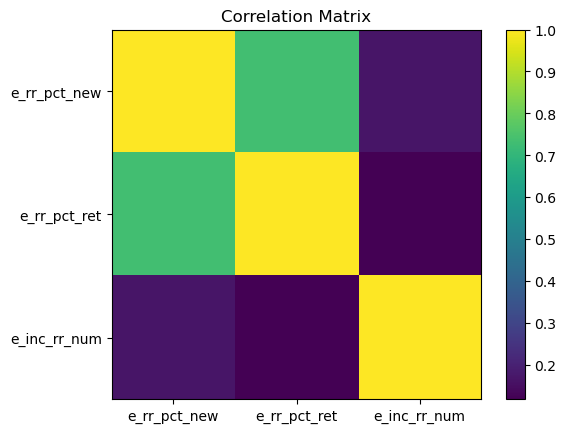

Number of Outliers: 193


In [12]:
# 1. Correlation matrix - take three column names
corr = df[["e_rr_pct_new","e_rr_pct_ret","e_inc_rr_num"]].corr()
print("Correlation Matrix:\n", corr)

# Correlation Visualisation plot
plt.imshow(corr); plt.colorbar()
plt.xticks(range(3), corr.columns); plt.yticks(range(3), corr.columns)
plt.title("Correlation Matrix"); plt.show()

# 2. Outlier detection using IQR
Q1, Q3 = df["e_rr_pct_new"].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df.query("e_rr_pct_new < @Q1-1.5*@IQR or e_rr_pct_new > @Q3+1.5*@IQR")

print("Number of Outliers:", outliers.shape[0])

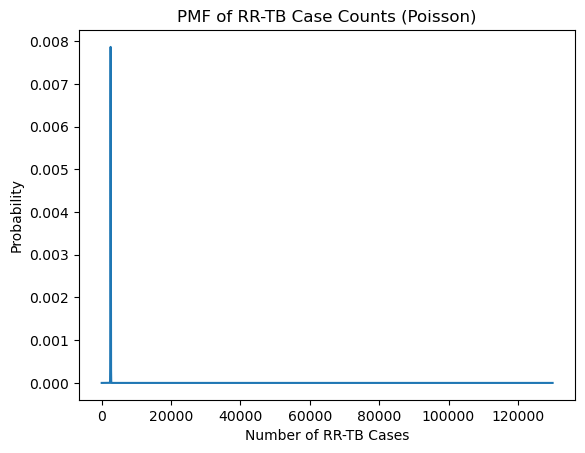

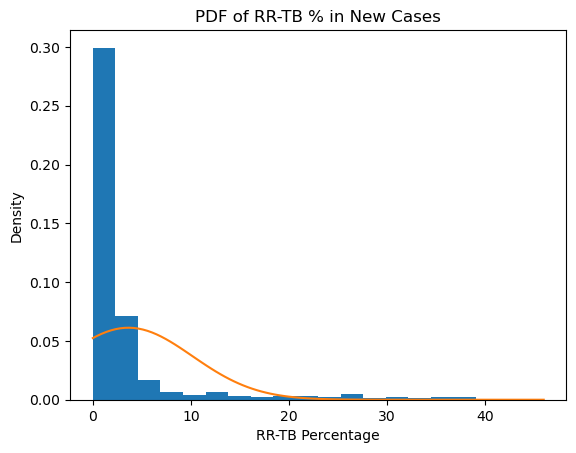

DISTRIBUTION PARAMETERS


,Parameter,Value
0,Poisson λ,2571.768802
1,Normal μ,3.635655
2,Normal σ,6.514339


In [13]:
# STEP-4 RANDOM VARIABLES & PROBABILITY
# =====================================

# Define Discrete(count data) and Continuous(percentage) Variables
X, Y = df["e_inc_rr_num"], df["e_rr_pct_new"]

# Poisson PMF (discrete) Distribution
x = np.arange(X.max()); lam = X.mean()
plt.plot(x, poisson.pmf(x, lam))
plt.title("PMF of RR-TB Case Counts (Poisson)")
plt.xlabel("Number of RR-TB Cases"); plt.ylabel("Probability"); plt.show()

# Normal PDF (continuous) Distribution
mu, sigma = norm.fit(Y); x = np.linspace(Y.min(), Y.max(), 100)
plt.hist(Y, bins=20, density=True); plt.plot(x, norm.pdf(x, mu, sigma))
plt.title("PDF of RR-TB % in New Cases")
plt.xlabel("RR-TB Percentage"); plt.ylabel("Density"); plt.show()

# Parameter summary table
results = pd.DataFrame({"Parameter":["Poisson λ","Normal μ","Normal σ"],
                        "Value":[lam, mu, sigma]})
print("DISTRIBUTION PARAMETERS"); display(results)

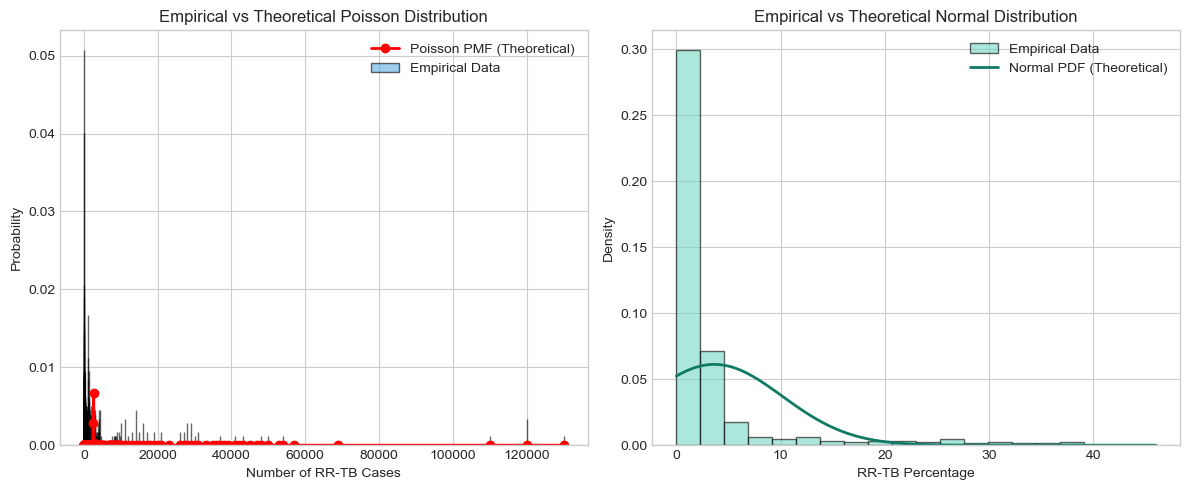

DISTRIBUTION PARAMETERS


,Parameter,Value
0,Estimated Poisson λ,2571.768802
1,Estimated Mean,3.635655
2,Estimated Std Dev,6.514339


In [14]:
# STEP-5 PROBABILITY FUNCTIONS - DISCRETE AND CONTINUOUS
# =====================================================

# Select two variables

# Discrete variable (RR-TB case counts)
X = df["e_inc_rr_num"].dropna() 
# Continuous variable (RR-TB percentage)
Y = df["e_rr_pct_new"].dropna()     

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(12,5))


# 1. Discrete Distribution Fit - (Poisson)
#------------------------------------

lambda_val = np.mean(X)
values, counts = np.unique(X, return_counts=True)
empirical_prob = counts / len(X)
poisson_prob = poisson.pmf(values, lambda_val)

axes[0].bar(values, empirical_prob, alpha=0.6, color="#5DADE2",
            edgecolor="black", label="Empirical Data")
axes[0].plot(values, poisson_prob, 'ro-', linewidth=2,
             label="Poisson PMF (Theoretical)")
axes[0].set_title("Empirical vs Theoretical Poisson Distribution")
axes[0].set_xlabel("Number of RR-TB Cases")
axes[0].set_ylabel("Probability")
axes[0].legend()


# 2. Continuous Distribution Fit – (Normal)
#------------------------------------------

mu, sigma = norm.fit(Y)
x = np.linspace(min(Y), max(Y), 100)
pdf = norm.pdf(x, mu, sigma)

axes[1].hist(Y, bins=20, density=True, alpha=0.6,
             color="#76D7C4", edgecolor="black",
             label="Empirical Data")
axes[1].plot(x, pdf, color="#117A65", linewidth=2,
             label="Normal PDF (Theoretical)")
axes[1].set_title("Empirical vs Theoretical Normal Distribution")
axes[1].set_xlabel("RR-TB Percentage")
axes[1].set_ylabel("Density")
axes[1].legend()
plt.tight_layout()
plt.show()

# Parameter summary table
results = pd.DataFrame({"Parameter":["Estimated Poisson λ","Estimated Mean","Estimated Std Dev"],
                        "Value":[lam, mu, sigma]})
print("DISTRIBUTION PARAMETERS"); display(results)

In [15]:
# Empirical Validation of Theoretical Distribution Assumptions
#--------------------------------------------------------------
a = 0.05

exp = poisson.pmf(values, lambda_val)*len(X)
obs, exp = counts[exp>=5], exp[exp>=5]
exp *= obs.sum()/exp.sum()
chi,p = chisquare(obs,exp)

# GOF - Goodness-of-Fit

# Poisson test
print("Poisson GOF (α=0.05)\nChi²=%.3f p=%.5f"%(chi,p))
print("Evidence against H0\n" if p<a else "No evidence against H0\n")

# Normality test
ks,p = kstest(Y,'norm',args=(mu,sigma))
print("Normality Test (α=0.05)\nKS=%.3f p=%.5f"%(ks,p))
print("Evidence against H0" if p<a else "No evidence against H0")

Poisson GOF (α=0.05)
Chi²=5.624 p=0.01772
Evidence against H0

Normality Test (α=0.05)
KS=0.331 p=0.00000
Evidence against H0
